# Tesseract vs EasyOCR vs PaddleOCR vs CNN: Single-Character Recognition Benchmark

**Author:** [TildAlice](https://tildalice.io) | Full blog post: [Tesseract vs EasyOCR vs PaddleOCR Benchmark](https://tildalice.io/ocr-tesseract-easyocr-paddleocr-benchmark/)

## What This Notebook Covers

Our [blog benchmark](https://tildalice.io/ocr-tesseract-easyocr-paddleocr-benchmark/) tested these engines on **real document images** — invoices, scanned PDFs, and scene text. Here, we flip the script: **single-character recognition** on 34×35 pixel grayscale images.

| Engine | Blog (Documents) FPS | Blog CER | This Notebook (Single Chars) |
|--------|---------------------|----------|-----------------------------|
| Tesseract | 8.2 | 0.18 | ? |
| EasyOCR | 3.1 | 0.09 | ? |
| PaddleOCR | 12.7 | 0.10 | ? |
| **CNN (baseline)** | — | — | ? |

**Key question:** OCR engines are designed for multi-character text with language context. What happens when you strip away that context entirely?

**Dataset:** [Standard OCR Dataset](https://www.kaggle.com/datasets/preatcher/standard-ocr-dataset) — 36 classes (0-9, A-Z), ~25K images

---

## 0. Install Dependencies (Kaggle)

Kaggle already has TensorFlow and scikit-learn. We just need the three OCR engines + system-level Tesseract binary.

In [1]:
!pip install -q pytesseract easyocr paddleocr paddlepaddle-gpu
!apt-get install -qq tesseract-ocr > /dev/null 2>&1
print("All OCR engines installed!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.9/67.9 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 758.9/758.9 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 767.5/767.5 kB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 MB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 

In [2]:
import os
import time
import glob
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({
    'figure.figsize': (14, 6), 'font.size': 11,
    'axes.titlesize': 14, 'axes.labelsize': 12, 'figure.dpi': 100,
})

# Color palette (consistent with TildAlice notebooks)
C = {
    'blue': '#4361ee', 'green': '#22c55e', 'red': '#ef4444',
    'yellow': '#eab308', 'purple': '#a855f7', 'cyan': '#06b6d4',
    'gray': '#94a3b8', 'orange': '#f97316',
}

CLASSES = [str(i) for i in range(10)] + [chr(c) for c in range(ord('A'), ord('Z') + 1)]
NUM_CLASSES = len(CLASSES)
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
IDX_TO_CLASS = {i: c for c, i in CLASS_TO_IDX.items()}

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Local dataset path (ajustado a tu carpeta "OCR")
DATA_ROOT = os.getenv('OCR_DATA_ROOT', './OCR')

print(f'Data root: {DATA_ROOT}')
print(f'Device: {DEVICE}')
print(f'Classes: {NUM_CLASSES} ({CLASSES[0]}..{CLASSES[9]}, {CLASSES[10]}..{CLASSES[-1]})')
print('Libraries loaded.')

Data root: ./OCR
Device: cpu
Classes: 36 (0..9, A..Z)
Libraries loaded.


---
## 2. Data Loading & EDA

In [3]:
def load_dataset_df(split_path, split_name):
    """Load image paths and labels into a DataFrame."""
    records = []
    skipped = 0
    for cls in CLASSES:
        cls_dir = os.path.join(split_path, cls)
        if not os.path.isdir(cls_dir):
            continue
        for fname in sorted(os.listdir(cls_dir)):
            if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                fpath = os.path.join(cls_dir, fname)
                # Skip empty/corrupt files
                if os.path.getsize(fpath) < 10:
                    skipped += 1
                    continue
                try:
                    Image.open(fpath).verify()
                    records.append({
                        'path': fpath,
                        'label': cls,
                        'label_idx': CLASS_TO_IDX[cls],
                        'split': split_name,
                    })
                except Exception:
                    skipped += 1
    if skipped:
        print(f'  [{split_name}] Skipped {skipped} corrupt/empty files')
    return pd.DataFrame(records)

train_df = load_dataset_df(os.path.join(DATA_ROOT, 'data', 'training_data'), 'train')
test_df  = load_dataset_df(os.path.join(DATA_ROOT, 'data', 'testing_data'), 'test')
test2_df = load_dataset_df(os.path.join(DATA_ROOT, 'data2', 'testing_data'), 'test2')

print(f'Training:   {len(train_df):>6,} images ({len(train_df)//NUM_CLASSES}/class)')
print(f'Test Set 1: {len(test_df):>6,} images ({len(test_df)//NUM_CLASSES}/class)')
print(f'Test Set 2: {len(test2_df):>6,} images')
print(f'Total:      {len(train_df)+len(test_df)+len(test2_df):>6,} images')

# Sample image dimensions
sample_sizes = []
for path in train_df['path'].sample(500, random_state=42):
    img = Image.open(path)
    sample_sizes.append({'width': img.size[0], 'height': img.size[1]})
size_df = pd.DataFrame(sample_sizes)
print(f'\nImage size — W: {size_df.width.mean():.0f}±{size_df.width.std():.1f}, '
      f'H: {size_df.height.mean():.0f}±{size_df.height.std():.1f}')

  [test2] Skipped 1 corrupt/empty files
Training:   20,628 images (573/class)
Test Set 1:  1,008 images (28/class)
Test Set 2:  3,241 images
Total:      24,877 images

Image size — W: 30±7.6, H: 38±3.3


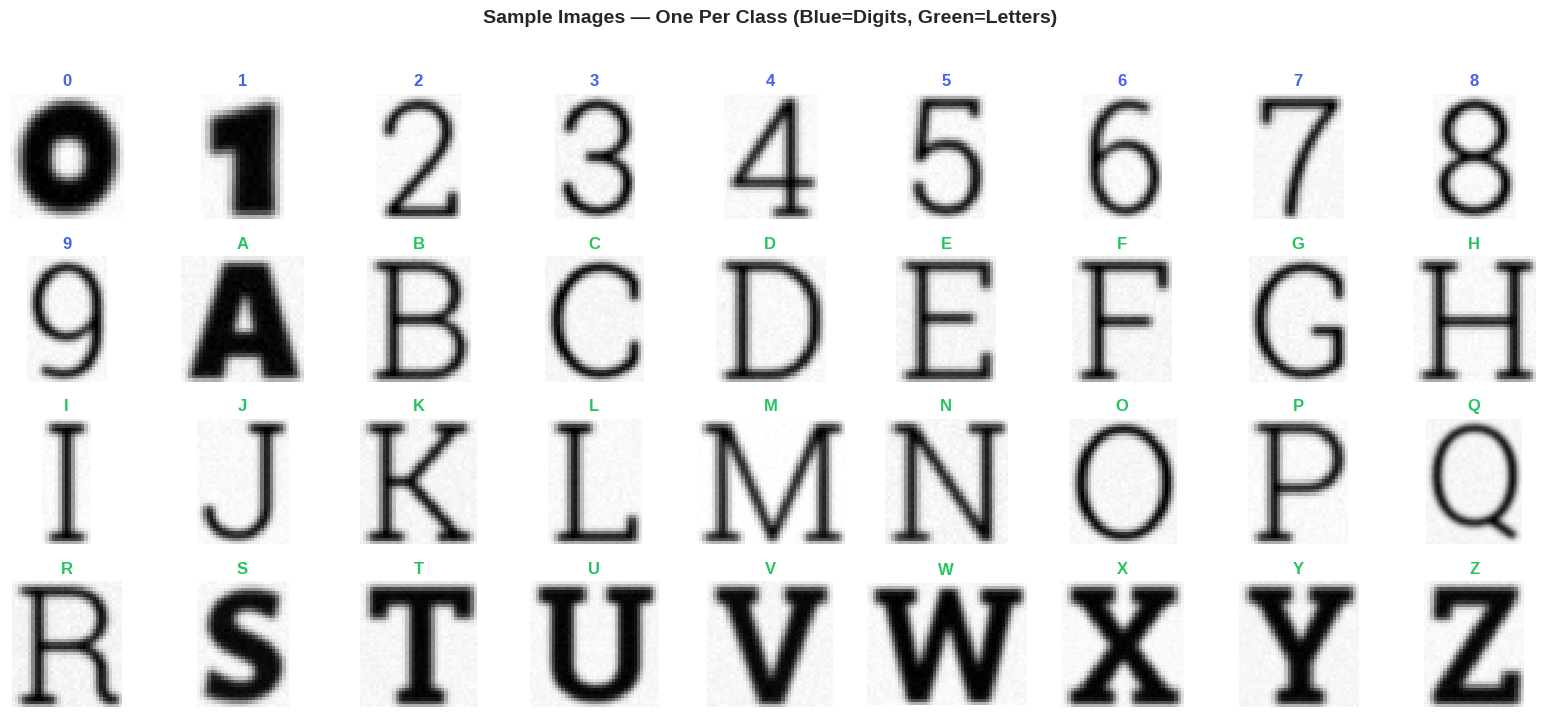

In [4]:
# Sample grid — one image per class (4 rows x 9 cols)
fig, axes = plt.subplots(4, 9, figsize=(16, 7))
axes = axes.flatten()

for i, cls in enumerate(CLASSES):
    cls_imgs = train_df[train_df['label'] == cls]
    sample_path = cls_imgs.iloc[0]['path']
    img = Image.open(sample_path)
    axes[i].imshow(np.array(img), cmap='gray')
    is_digit = cls.isdigit()
    axes[i].set_title(cls, fontweight='bold', fontsize=12,
                      color=C['blue'] if is_digit else C['green'])
    axes[i].axis('off')

for j in range(len(CLASSES), len(axes)):
    axes[j].axis('off')

fig.suptitle('Sample Images — One Per Class (Blue=Digits, Green=Letters)',
             fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

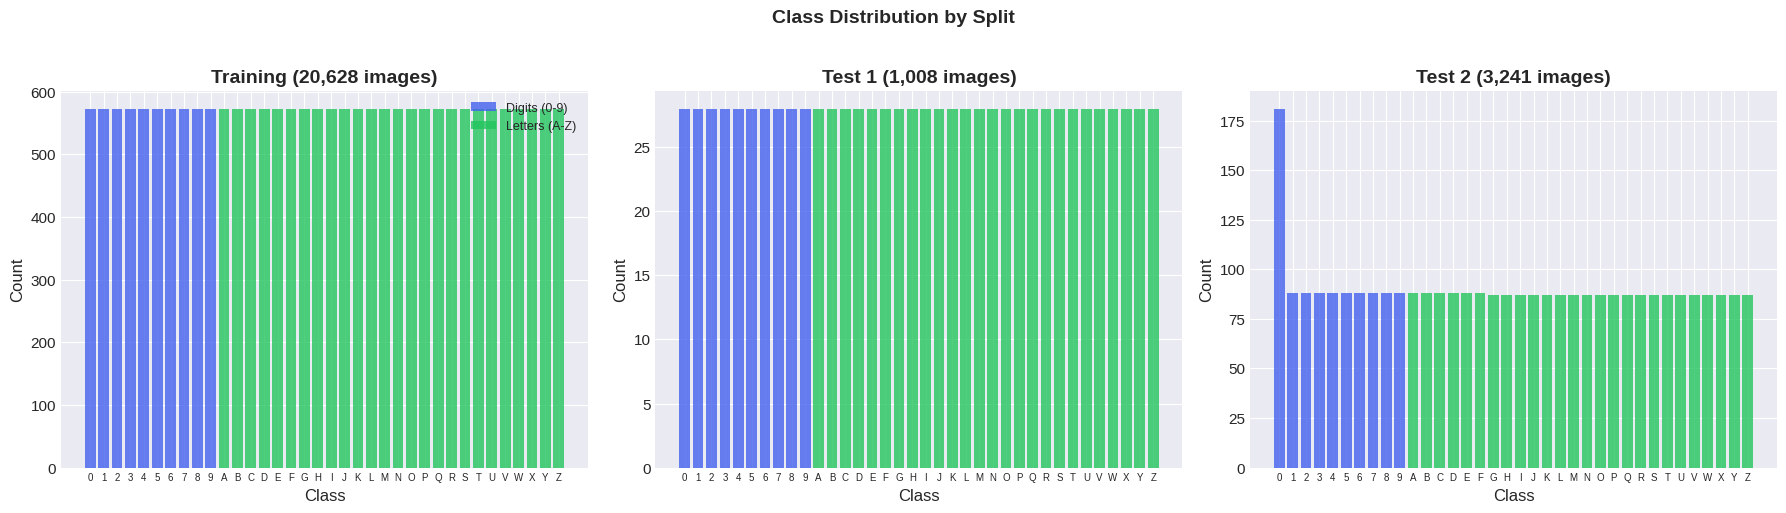

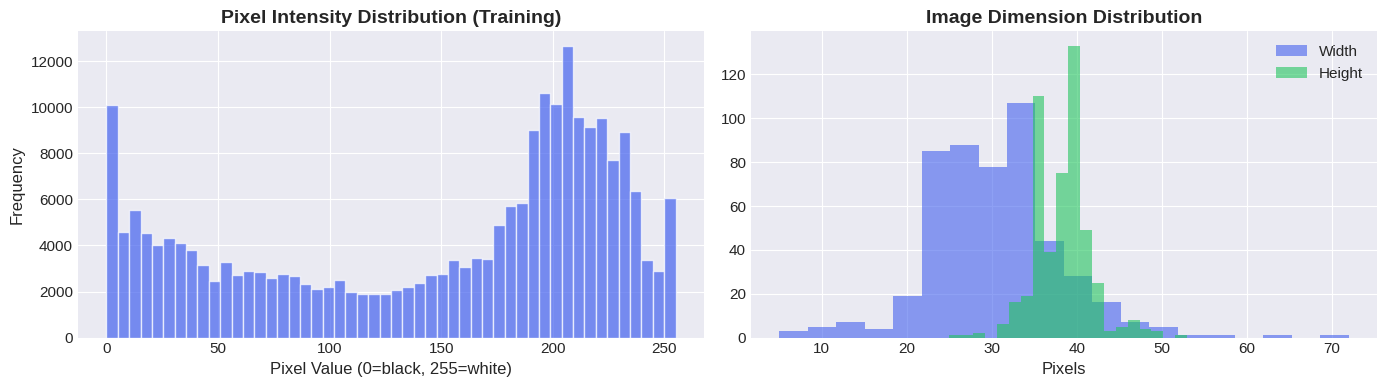

In [5]:
# Class distribution across splits
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (df_split, name) in zip(axes, [(train_df, 'Training'), (test_df, 'Test 1'), (test2_df, 'Test 2')]):
    counts = df_split['label'].value_counts().reindex(CLASSES).fillna(0)
    colors = [C['blue'] if c.isdigit() else C['green'] for c in CLASSES]
    ax.bar(CLASSES, counts, color=colors, alpha=0.8)
    ax.set_title(f'{name} ({len(df_split):,} images)', fontweight='bold')
    ax.set_xlabel('Class')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', labelsize=7)

legend_el = [Patch(facecolor=C['blue'], alpha=0.8, label='Digits (0-9)'),
             Patch(facecolor=C['green'], alpha=0.8, label='Letters (A-Z)')]
axes[0].legend(handles=legend_el, fontsize=9)

fig.suptitle('Class Distribution by Split', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Pixel intensity distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

intensities = []
for path in train_df['path'].sample(200, random_state=42):
    img = np.array(Image.open(path))
    intensities.extend(img.flatten())

axes[0].hist(intensities, bins=50, color=C['blue'], alpha=0.7, edgecolor='white')
axes[0].set_title('Pixel Intensity Distribution (Training)', fontweight='bold')
axes[0].set_xlabel('Pixel Value (0=black, 255=white)')
axes[0].set_ylabel('Frequency')

axes[1].hist(size_df['width'], bins=20, alpha=0.6, color=C['blue'], label='Width')
axes[1].hist(size_df['height'], bins=20, alpha=0.6, color=C['green'], label='Height')
axes[1].set_title('Image Dimension Distribution', fontweight='bold')
axes[1].set_xlabel('Pixels')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 3. Preprocessing

Two pipelines:
- **CNN**: resize to 32×32, normalize to [0,1]
- **OCR engines**: pad + upscale to 128×128 (OCR engines need larger images with margins)

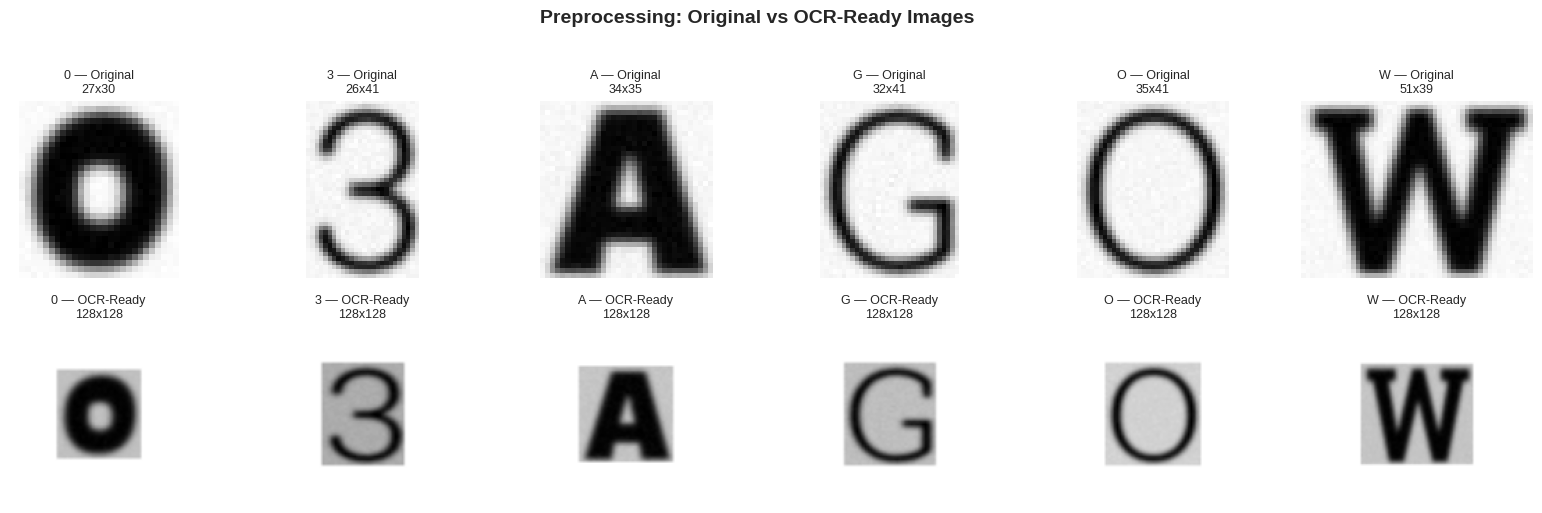

In [6]:
def prepare_for_ocr(image_path, target_size=128, padding=15):
    """Prepare single-char image for OCR: pad + upscale."""
    img = Image.open(image_path).convert('L')
    w, h = img.size
    # Add white padding
    padded = Image.new('L', (w + 2*padding, h + 2*padding), 255)
    padded.paste(img, (padding, padding))
    # Upscale
    padded = padded.resize((target_size, target_size), Image.BILINEAR)
    return np.array(padded)

# Visual comparison: original vs OCR-ready
fig, axes = plt.subplots(2, 6, figsize=(16, 5))
sample_classes = ['0', '3', 'A', 'G', 'O', 'W']

for i, cls in enumerate(sample_classes):
    sample_path = train_df[train_df['label'] == cls].iloc[0]['path']
    
    # Original
    orig = np.array(Image.open(sample_path).convert('L'))
    axes[0, i].imshow(orig, cmap='gray')
    axes[0, i].set_title(f'{cls} — Original\n{orig.shape[1]}x{orig.shape[0]}', fontsize=9)
    axes[0, i].axis('off')
    
    # OCR-ready
    ocr_img = prepare_for_ocr(sample_path)
    axes[1, i].imshow(ocr_img, cmap='gray')
    axes[1, i].set_title(f'{cls} — OCR-Ready\n128x128', fontsize=9)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Padded+Upscaled', fontsize=11, fontweight='bold')
fig.suptitle('Preprocessing: Original vs OCR-Ready Images', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [4]:
# PyTorch Dataset
class OCRDataset(Dataset):
    def __init__(self, df, img_size=32):
        self.df = df.reset_index(drop=True)
        self.img_size = img_size
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['path']).convert('L').resize((self.img_size, self.img_size), Image.BILINEAR)
        x = torch.tensor(np.array(img), dtype=torch.float32).unsqueeze(0) / 255.0  # (1, H, W)
        y = row['label_idx']
        return x, y

train_ds = OCRDataset(train_df)
test_ds = OCRDataset(test_df)
test2_ds = OCRDataset(test2_df)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False, num_workers=2, pin_memory=True)
test2_loader = DataLoader(test2_ds, batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train: {len(train_ds):,} images  ({len(train_loader)} batches)')
print(f'Test1: {len(test_ds):,} images')
print(f'Test2: {len(test2_ds):,} images')

Train: 20,628 images  (323 batches)
Test1: 1,008 images
Test2: 3,241 images


---
## 4. CNN Baseline

A simple CNN should dominate on this task — it's essentially image classification, exactly what CNNs are built for. This serves as our "ceiling" performance.

In [5]:
class CharCNN(nn.Module):
    def __init__(self, num_classes=36):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.BatchNorm2d(32),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),
            
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.BatchNorm2d(64),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),
            
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.BatchNorm2d(128),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )
    
    def forward(self, x):
        return self.classifier(self.features(x))

model = CharCNN(NUM_CLASSES).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
print(f'Model parameters: {total_params:,}')
print(model)

Model parameters: 673,092
CharCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Dropout2d(p=0.25, inplace=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU()
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU()
    (12): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (13): Dropout2d(p=0.25, inplace=False)
    (14): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU()
    (16): BatchNorm2d(128, eps=1e-05, momentum=0

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=3)

history = {'train_acc': [], 'val_acc': [], 'train_loss': [], 'val_loss': []}
best_val_acc = 0
patience_counter = 0

for epoch in range(30):
    # Train
    model.train()
    running_loss, correct, total = 0, 0, 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        out = model(X_batch)
        loss = criterion(out, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * len(y_batch)
        correct += (out.argmax(1) == y_batch).sum().item()
        total += len(y_batch)
    
    train_loss = running_loss / total
    train_acc = correct / total
    
    # Validate
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            out = model(X_batch)
            val_loss += criterion(out, y_batch).item() * len(y_batch)
            val_correct += (out.argmax(1) == y_batch).sum().item()
            val_total += len(y_batch)
    
    val_loss /= val_total
    val_acc = val_correct / val_total
    scheduler.step(val_loss)
    
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    
    lr = optimizer.param_groups[0]['lr']
    print(f'Epoch {epoch+1:2d} | Train {train_acc:.4f} | Val {val_acc:.4f} | '
          f'Loss {val_loss:.4f} | LR {lr:.1e}')
    
    # Early stopping
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= 7:
            print(f'Early stopping at epoch {epoch+1}')
            break

model.load_state_dict(best_state)
model.to(DEVICE)
print(f'\nBest validation accuracy: {best_val_acc:.4f}')

# Learning curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history['train_acc'], color=C['blue'], lw=1.5, label='Train')
ax1.plot(history['val_acc'], color=C['green'], lw=1.5, label='Validation')
ax1.set_title('CNN Accuracy', fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.set_ylim(0.5, 1.02)

ax2.plot(history['train_loss'], color=C['blue'], lw=1.5, label='Train')
ax2.plot(history['val_loss'], color=C['green'], lw=1.5, label='Validation')
ax2.set_title('CNN Loss', fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

Traceback (most recent call last):
  File "<string>", line 1, in <module>
  File "/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/multiprocessing/spawn.py", line 116, in spawn_main
    exitcode = _main(fd, parent_sentinel)
  File "/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/multiprocessing/spawn.py", line 126, in _main
    self = reduction.pickle.load(from_parent)
AttributeError: Can't get attribute 'OCRDataset' on <module '__main__' (built-in)>


KeyboardInterrupt: 

In [10]:
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(DEVICE)
        preds = model(X_batch).argmax(1).cpu()
        all_preds.append(preds)
        all_labels.append(y_batch)
    return torch.cat(all_preds).numpy(), torch.cat(all_labels).numpy()

# Evaluate
cnn_preds, y_test_np = evaluate(model, test_loader)
cnn_preds2, y_test2_np = evaluate(model, test2_loader)

test1_acc = (cnn_preds == y_test_np).mean()
test2_acc = (cnn_preds2 == y_test2_np).mean()

# FPS measurement
model.eval()
dummy = torch.randn(len(test_ds), 1, 32, 32).to(DEVICE)
torch.cuda.synchronize() if DEVICE.type == 'cuda' else None
start = time.time()
with torch.no_grad():
    _ = model(dummy)
torch.cuda.synchronize() if DEVICE.type == 'cuda' else None
cnn_fps = len(test_ds) / (time.time() - start)

# Per-class accuracy
cnn_per_class = {}
for cls in CLASSES:
    idx = CLASS_TO_IDX[cls]
    mask = y_test_np == idx
    if mask.sum() > 0:
        cnn_per_class[cls] = (cnn_preds[mask] == idx).mean()

total_params = sum(p.numel() for p in model.parameters())
print('=== CNN Results ===')
print(f'  Test 1 Accuracy: {test1_acc:.4f} ({test1_acc*100:.1f}%)')
print(f'  Test 2 Accuracy: {test2_acc:.4f} ({test2_acc*100:.1f}%)')
print(f'  Throughput:      {cnn_fps:.0f} FPS')
print(f'  Parameters:      {total_params:,}')

# Store results
results = {}
results['CNN'] = {
    'accuracy': test1_acc,
    'accuracy_test2': test2_acc,
    'fps': cnn_fps,
    'empty_rate': 0.0,
    'per_class': cnn_per_class,
    'predictions': cnn_preds,
}

=== CNN Results ===
  Test 1 Accuracy: 0.9891 (98.9%)
  Test 2 Accuracy: 0.9861 (98.6%)
  Throughput:      34288 FPS
  Parameters:      673,092


---
## 4.1 Exportar el modelo (reutilizable)

Guarda el CNN entrenado en un formato portable para usarlo luego en otro proyecto o script.

In [ ]:
import json
from pathlib import Path

EXPORT_DIR = Path("./exports")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

model_path = EXPORT_DIR / "charcnn_state_dict.pt"
meta_path = EXPORT_DIR / "charcnn_metadata.json"

# Guardar pesos
torch.save(model.state_dict(), model_path)

# Guardar metadata mínima para reconstruir el modelo
metadata = {
    "num_classes": NUM_CLASSES,
    "classes": CLASSES,
    "input_size": 32,
    "grayscale": True,
    "arch": "CharCNN",
}
meta_path.write_text(json.dumps(metadata, indent=2), encoding="utf-8")

print(f"Modelo guardado en: {model_path}")
print(f"Metadata guardada en: {meta_path}")

# (Opcional) Ejemplo de carga rápida
# model2 = CharCNN(num_classes=metadata["num_classes"]).to(DEVICE)
# model2.load_state_dict(torch.load(model_path, map_location=DEVICE))
# model2.eval()

---
## 5. OCR Benchmark Framework

We test each OCR engine on the same test set. Key metrics:
- **Accuracy**: exact match (predicted char == ground truth)
- **FPS**: images processed per second
- **Empty rate**: % of images where the engine returned no text
- **Per-class accuracy**: which characters are hardest?

In [11]:
def benchmark_ocr_engine(name, predict_fn, df, max_samples=None):
    """Benchmark an OCR engine on a test DataFrame.
    
    predict_fn(image_path) -> str (predicted character, uppercase)
    """
    if max_samples:
        df = df.sample(n=min(max_samples, len(df)), random_state=42).reset_index(drop=True)
    
    predictions = []
    correct = 0
    empty = 0
    per_class_correct = Counter()
    per_class_total = Counter()
    
    start = time.time()
    for _, row in df.iterrows():
        try:
            pred = predict_fn(row['path'])
        except Exception:
            pred = ''
        
        pred = pred.strip().upper()[:1] if pred else ''
        predictions.append(pred)
        
        label = row['label'].upper()
        per_class_total[label] += 1
        
        if not pred:
            empty += 1
        elif pred == label:
            correct += 1
            per_class_correct[label] += 1
    
    elapsed = time.time() - start
    n = len(df)
    
    per_class_acc = {}
    for cls in CLASSES:
        total = per_class_total[cls]
        if total > 0:
            per_class_acc[cls] = per_class_correct[cls] / total
        else:
            per_class_acc[cls] = 0.0
    
    result = {
        'accuracy': correct / n,
        'fps': n / elapsed,
        'empty_rate': empty / n,
        'per_class': per_class_acc,
        'predictions': predictions,
        'n_samples': n,
    }
    
    print(f'\n=== {name} Results ===')
    print(f'  Accuracy:   {result["accuracy"]:.4f} ({result["accuracy"]*100:.1f}%)')
    print(f'  FPS:        {result["fps"]:.1f}')
    print(f'  Empty rate: {result["empty_rate"]:.2%}')
    print(f'  Time:       {elapsed:.1f}s for {n} images')
    
    return result

---
## 6. Tesseract OCR

Tesseract is the most widely-used open-source OCR engine. `--psm 10` enables single character mode. We also restrict the character whitelist to improve results.

> In our [blog benchmark](https://tildalice.io/ocr-tesseract-easyocr-paddleocr-benchmark/), Tesseract achieved **8.2 FPS** and **0.18 CER** on document images.

In [12]:
try:
    import pytesseract
    
    TESS_CONFIG = '--psm 10 -c tessedit_char_whitelist=0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ'
    
    def tesseract_predict(image_path):
        img = prepare_for_ocr(image_path)
        pil_img = Image.fromarray(img)
        text = pytesseract.image_to_string(pil_img, config=TESS_CONFIG)
        return text.strip()
    
    # Quick test
    sample = train_df.iloc[0]['path']
    print(f'Tesseract test: {train_df.iloc[0]["label"]} → "{tesseract_predict(sample)}"')
    
    results['Tesseract'] = benchmark_ocr_engine('Tesseract', tesseract_predict, test_df)
    HAS_TESSERACT = True

except ImportError:
    print('pytesseract not installed. Skipping Tesseract benchmark.')
    print('Install: pip install pytesseract + brew install tesseract (macOS)')
    HAS_TESSERACT = False
except Exception as e:
    print(f'Tesseract error: {e}')
    print('Make sure tesseract-ocr is installed on the system.')
    HAS_TESSERACT = False

Tesseract test: 0 → "O"

=== Tesseract Results ===
  Accuracy:   0.7073 (70.7%)
  FPS:        9.0
  Empty rate: 21.03%
  Time:       111.9s for 1008 images


---
## 7. EasyOCR

EasyOCR uses a CRNN (CNN + BiLSTM + CTC) architecture. It's designed for scene text recognition.

> In our [blog benchmark](https://tildalice.io/ocr-tesseract-easyocr-paddleocr-benchmark/), EasyOCR was the **most accurate** (0.09 CER) but **slowest** (3.1 FPS).

In [13]:
try:
    import easyocr
    
    import torch
    USE_GPU = torch.cuda.is_available()
    print(f'EasyOCR GPU: {USE_GPU}')
    reader = easyocr.Reader(['en'], gpu=USE_GPU, verbose=False)
    ALLOWLIST = '0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ'
    
    def easyocr_predict(image_path):
        img = prepare_for_ocr(image_path)
        result = reader.readtext(img, allowlist=ALLOWLIST, detail=0)
        return result[0] if result else ''
    
    # Quick test
    sample = train_df.iloc[0]['path']
    print(f'EasyOCR test: {train_df.iloc[0]["label"]} -> "{easyocr_predict(sample)}"')
    
    results['EasyOCR'] = benchmark_ocr_engine('EasyOCR', easyocr_predict, test_df)
    HAS_EASYOCR = True

except ImportError:
    print('easyocr not installed. Skipping EasyOCR benchmark.')
    print('Install: pip install easyocr')
    HAS_EASYOCR = False
except Exception as e:
    print(f'EasyOCR error: {e}')
    HAS_EASYOCR = False

EasyOCR GPU: True
EasyOCR test: 0 -> "0"

=== EasyOCR Results ===
  Accuracy:   0.7927 (79.3%)
  FPS:        51.6
  Empty rate: 11.90%
  Time:       19.5s for 1008 images


---
## 8. PaddleOCR

PaddleOCR is Baidu's high-performance OCR system. It was the **fastest** engine in our blog benchmark.

> In our [blog benchmark](https://tildalice.io/ocr-tesseract-easyocr-paddleocr-benchmark/), PaddleOCR achieved **12.7 FPS** with **0.10 CER** — the best speed/accuracy balance.

In [14]:
try:
    import logging
    logging.getLogger('ppocr').setLevel(logging.ERROR)
    from paddleocr import PaddleOCR
    
    paddle = PaddleOCR(lang='en', use_angle_cls=False)
    
    def paddleocr_predict(image_path):
        img = prepare_for_ocr(image_path)
        result = paddle.ocr(img, cls=False)
        if result and result[0]:
            texts = []
            for line in result[0]:
                if line and len(line) >= 2:
                    texts.append(line[1][0])
            return texts[0] if texts else ''
        return ''
    
    # Quick test
    sample = train_df.iloc[0]['path']
    print(f'PaddleOCR test: {train_df.iloc[0]["label"]} -> "{paddleocr_predict(sample)}"')
    
    results['PaddleOCR'] = benchmark_ocr_engine('PaddleOCR', paddleocr_predict, test_df)
    HAS_PADDLE = True

except ImportError:
    print('paddleocr not installed. Skipping PaddleOCR benchmark.')
    print('Install: pip install paddleocr paddlepaddle')
    HAS_PADDLE = False
except Exception as e:
    print(f'PaddleOCR error: {e}')
    HAS_PADDLE = False

Checking connectivity to the model hosters, this may take a while. To bypass this check, set `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` to `True`.
Creating model: ('PP-LCNet_x1_0_doc_ori', None)
Using official model (PP-LCNet_x1_0_doc_ori), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

inference.yml:   0%|          | 0.00/766 [00:00<?, ?B/s]

.gitattributes: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

README.md: 0.00B [00:00, ?B/s]

inference.json: 0.00B [00:00, ?B/s]

inference.pdiparams:   0%|          | 0.00/6.75M [00:00<?, ?B/s]

PaddleOCR error: 'paddle.base.libpaddle.AnalysisConfig' object has no attribute 'set_optimization_level'


---
## 9. Comparison Dashboard

Now let's compare all engines side by side. The results tell a clear story about **tool selection**.


=== Overall Comparison ===
   Engine Accuracy   FPS Empty Rate
      CNN    98.9% 34288       0.0%
Tesseract    70.7%     9      21.0%
  EasyOCR    79.3%    52      11.9%


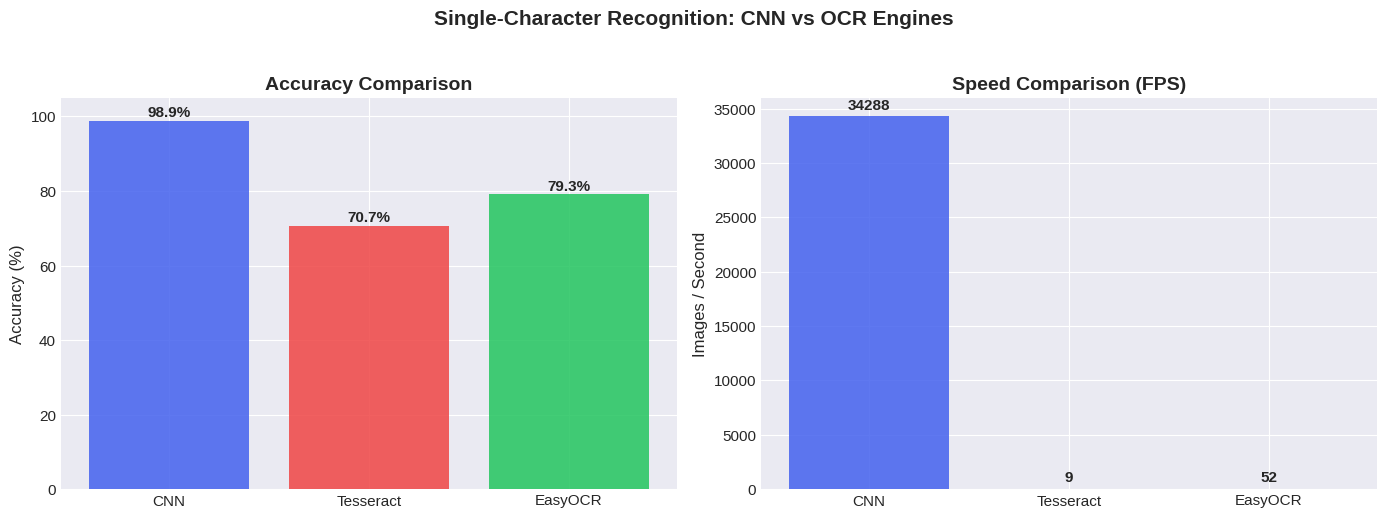

In [15]:
# Summary table
engines = list(results.keys())
summary_data = []
for eng in engines:
    r = results[eng]
    summary_data.append({
        'Engine': eng,
        'Accuracy': f"{r['accuracy']*100:.1f}%",
        'FPS': f"{r['fps']:.0f}",
        'Empty Rate': f"{r.get('empty_rate', 0):.1%}",
    })

summary_df = pd.DataFrame(summary_data)
print('\n=== Overall Comparison ===')
print(summary_df.to_string(index=False))

# Accuracy + Speed bar chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

engine_colors = {'CNN': C['blue'], 'Tesseract': C['red'], 'EasyOCR': C['green'], 'PaddleOCR': C['orange']}
bar_colors = [engine_colors.get(e, C['gray']) for e in engines]

accs = [results[e]['accuracy'] * 100 for e in engines]
bars1 = ax1.bar(engines, accs, color=bar_colors, alpha=0.85)
for bar, val in zip(bars1, accs):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11)
ax1.set_title('Accuracy Comparison', fontweight='bold', fontsize=14)
ax1.set_ylabel('Accuracy (%)')
ax1.set_ylim(0, 105)

fps_vals = [results[e]['fps'] for e in engines]
bars2 = ax2.bar(engines, fps_vals, color=bar_colors, alpha=0.85)
for bar, val in zip(bars2, fps_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(fps_vals)*0.02,
             f'{val:.0f}', ha='center', fontweight='bold', fontsize=11)
ax2.set_title('Speed Comparison (FPS)', fontweight='bold', fontsize=14)
ax2.set_ylabel('Images / Second')

fig.suptitle('Single-Character Recognition: CNN vs OCR Engines',
             fontweight='bold', fontsize=15, y=1.03)
plt.tight_layout()
plt.show()

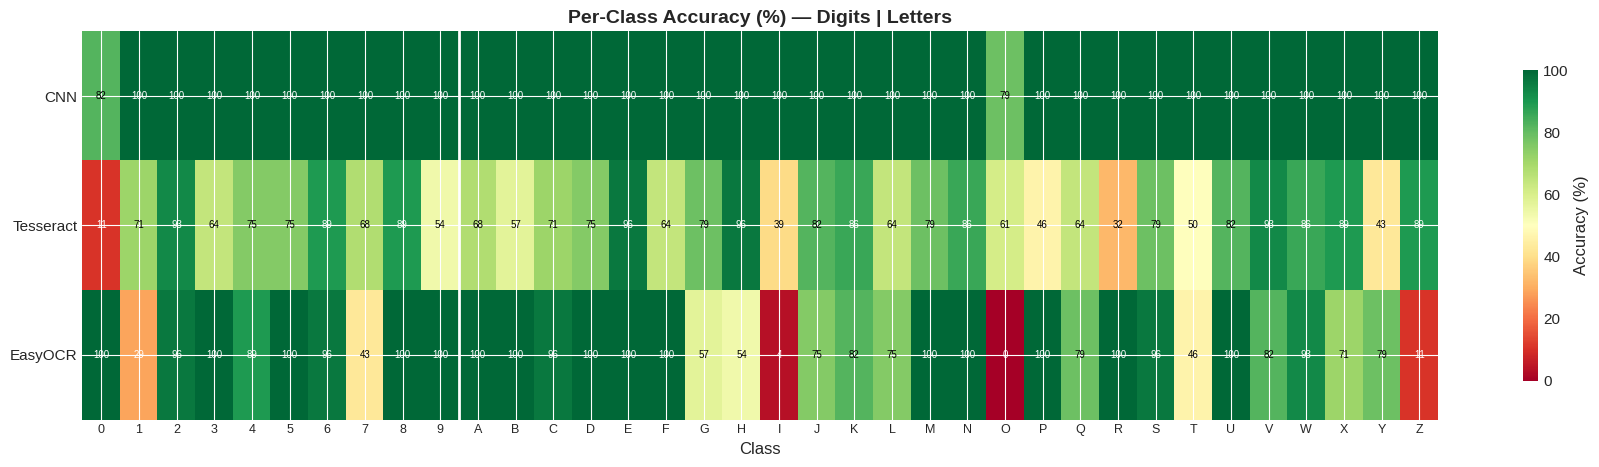


=== Hardest Classes (Lowest Accuracy) ===
  CNN         : O(79%), 0(82%), 1(100%)
  Tesseract   : 0(11%), R(32%), I(39%)
  EasyOCR     : O(0%), I(4%), Z(11%)


In [16]:
# Per-class accuracy heatmap
fig, ax = plt.subplots(figsize=(18, 3 + len(engines) * 0.6))

heatmap_data = np.zeros((len(engines), NUM_CLASSES))
for i, eng in enumerate(engines):
    for j, cls in enumerate(CLASSES):
        heatmap_data[i, j] = results[eng]['per_class'].get(cls, 0) * 100

im = ax.imshow(heatmap_data, cmap='RdYlGn', aspect='auto', vmin=0, vmax=100)
ax.set_xticks(range(NUM_CLASSES))
ax.set_xticklabels(CLASSES, fontsize=9)
ax.set_yticks(range(len(engines)))
ax.set_yticklabels(engines, fontsize=11)

for i in range(len(engines)):
    for j in range(NUM_CLASSES):
        val = heatmap_data[i, j]
        color = 'white' if val < 30 or val > 85 else 'black'
        ax.text(j, i, f'{val:.0f}', ha='center', va='center', fontsize=7, color=color)

# Digit/letter divider
ax.axvline(x=9.5, color='white', lw=2)
ax.set_xlabel('Class')
ax.set_title('Per-Class Accuracy (%) — Digits | Letters', fontweight='bold', fontsize=14)
plt.colorbar(im, ax=ax, label='Accuracy (%)', shrink=0.8)

plt.tight_layout()
plt.show()

# Find hardest classes for each engine
print('\n=== Hardest Classes (Lowest Accuracy) ===')
for eng in engines:
    pc = results[eng]['per_class']
    sorted_cls = sorted(pc.items(), key=lambda x: x[1])
    bottom3 = ', '.join([f'{c}({v*100:.0f}%)' for c, v in sorted_cls[:3]])
    print(f'  {eng:12s}: {bottom3}')

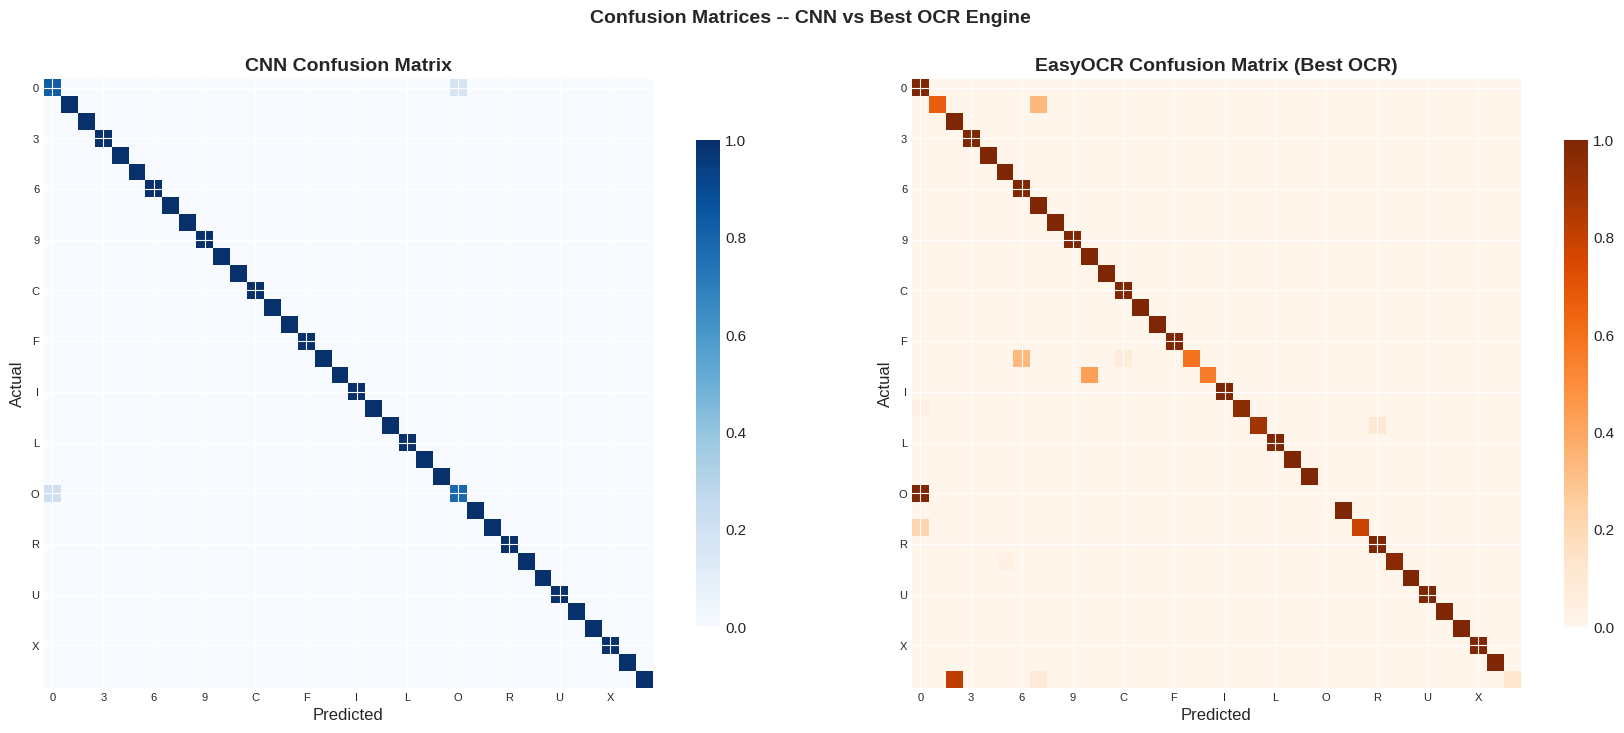

In [17]:
# Confusion matrix for CNN
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# CNN confusion matrix
cm_cnn = confusion_matrix(y_test_np, results['CNN']['predictions'], labels=range(NUM_CLASSES))
cm_cnn_norm = cm_cnn.astype(float) / cm_cnn.sum(axis=1, keepdims=True)

ax = axes[0]
im1 = ax.imshow(cm_cnn_norm, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(0, NUM_CLASSES, 3))
ax.set_xticklabels([CLASSES[i] for i in range(0, NUM_CLASSES, 3)], fontsize=8)
ax.set_yticks(range(0, NUM_CLASSES, 3))
ax.set_yticklabels([CLASSES[i] for i in range(0, NUM_CLASSES, 3)], fontsize=8)
ax.set_title('CNN Confusion Matrix', fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.colorbar(im1, ax=ax, shrink=0.8)

# Best OCR engine confusion matrix
ocr_engines = [e for e in engines if e != 'CNN']
if ocr_engines:
    best_ocr = max(ocr_engines, key=lambda e: results[e]['accuracy'])
    preds_ocr = results[best_ocr]['predictions']
    # Convert predictions to indices
    pred_indices = []
    for p in preds_ocr:
        p = p.strip().upper()[:1] if isinstance(p, str) and p else ''
        pred_indices.append(CLASS_TO_IDX.get(p, -1))
    
    # Filter valid predictions for confusion matrix
    valid_mask = [p >= 0 for p in pred_indices]
    valid_true = [y_test_np[i] for i, v in enumerate(valid_mask) if v]
    valid_pred = [pred_indices[i] for i, v in enumerate(valid_mask) if v]
    
    if valid_true:
        cm_ocr = confusion_matrix(valid_true, valid_pred, labels=range(NUM_CLASSES))
        cm_ocr_norm = np.zeros_like(cm_ocr, dtype=float)
        row_sums = cm_ocr.sum(axis=1, keepdims=True)
        mask = row_sums > 0
        cm_ocr_norm[mask.flatten()] = cm_ocr[mask.flatten()] / row_sums[mask]
    else:
        cm_ocr_norm = np.zeros((NUM_CLASSES, NUM_CLASSES))
    
    ax = axes[1]
    im2 = ax.imshow(cm_ocr_norm, cmap='Oranges', vmin=0, vmax=1)
    ax.set_xticks(range(0, NUM_CLASSES, 3))
    ax.set_xticklabels([CLASSES[i] for i in range(0, NUM_CLASSES, 3)], fontsize=8)
    ax.set_yticks(range(0, NUM_CLASSES, 3))
    ax.set_yticklabels([CLASSES[i] for i in range(0, NUM_CLASSES, 3)], fontsize=8)
    ax.set_title(f'{best_ocr} Confusion Matrix (Best OCR)', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    plt.colorbar(im2, ax=ax, shrink=0.8)
else:
    axes[1].text(0.5, 0.5, 'No OCR engines available',
                transform=axes[1].transAxes, ha='center', va='center', fontsize=14)
    axes[1].set_axis_off()

fig.suptitle('Confusion Matrices -- CNN vs Best OCR Engine', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [18]:
# Commonly confused character pairs analysis
confusing_pairs = [
    ('O', '0', 'O vs 0 (letter O / digit zero)'),
    ('I', '1', 'I vs 1 (letter I / digit one)'),
    ('S', '5', 'S vs 5'),
    ('B', '8', 'B vs 8'),
    ('Z', '2', 'Z vs 2'),
    ('G', '6', 'G vs 6'),
]

print('=== Commonly Confused Pairs ===')
print(f'{"Pair":<30s}', end='')
for eng in engines:
    print(f'{eng:>12s}', end='')
print()
print('-' * (30 + 12 * len(engines)))

for c1, c2, desc in confusing_pairs:
    print(f'{desc:<30s}', end='')
    for eng in engines:
        pc = results[eng]['per_class']
        acc1 = pc.get(c1, 0)
        acc2 = pc.get(c2, 0)
        avg = (acc1 + acc2) / 2
        print(f'{avg*100:>10.0f}%', end='  ')
    print()

# Blog vs Notebook comparison
print('\n\n=== Blog (Documents) vs Notebook (Single Chars) ===')
blog_results = {
    'Tesseract': {'fps': 8.2, 'cer': 0.18},
    'EasyOCR': {'fps': 3.1, 'cer': 0.09},
    'PaddleOCR': {'fps': 12.7, 'cer': 0.10},
}

print(f'{"Engine":<12s} {"Blog FPS":>10s} {"Blog CER":>10s} {"Notebook Acc":>14s} {"Notebook FPS":>14s}')
print('-' * 62)
for eng in ['Tesseract', 'EasyOCR', 'PaddleOCR']:
    blog = blog_results.get(eng, {})
    nb = results.get(eng, {})
    blog_fps = f"{blog['fps']:.1f}" if blog else 'N/A'
    blog_cer = f"{blog['cer']:.2f}" if blog else 'N/A'
    nb_acc = f"{nb['accuracy']*100:.1f}%" if nb else 'N/A'
    nb_fps = f"{nb['fps']:.1f}" if nb else 'N/A'
    print(f'{eng:<12s} {blog_fps:>10s} {blog_cer:>10s} {nb_acc:>14s} {nb_fps:>14s}')

=== Commonly Confused Pairs ===
Pair                                   CNN   Tesseract     EasyOCR
------------------------------------------------------------------
O vs 0 (letter O / digit zero)        80%          36%          50%  
I vs 1 (letter I / digit one)        100%          55%          16%  
S vs 5                               100%          77%          98%  
B vs 8                               100%          73%         100%  
Z vs 2                               100%          91%          54%  
G vs 6                               100%          84%          77%  


=== Blog (Documents) vs Notebook (Single Chars) ===
Engine         Blog FPS   Blog CER   Notebook Acc   Notebook FPS
--------------------------------------------------------------
Tesseract           8.2       0.18          70.7%            9.0
EasyOCR             3.1       0.09          79.3%           51.6
PaddleOCR          12.7       0.10            N/A            N/A


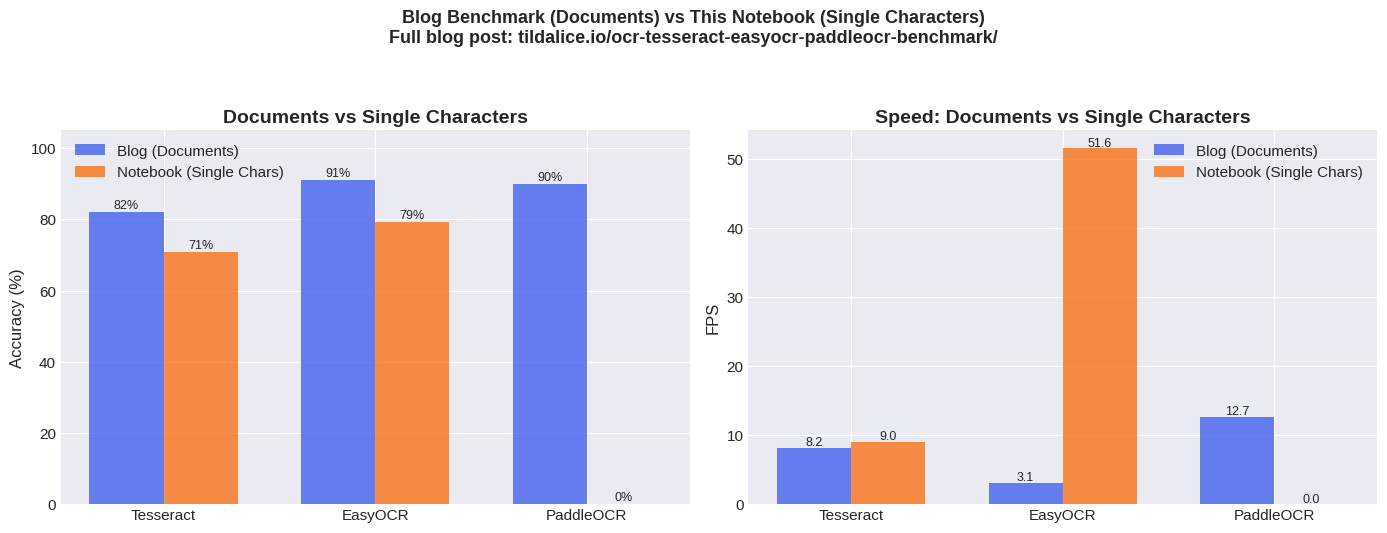

In [19]:
# Blog vs Notebook visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ocr_names = ['Tesseract', 'EasyOCR', 'PaddleOCR']
blog_cers = [blog_results[e]['cer'] for e in ocr_names]
blog_accs = [(1 - cer) * 100 for cer in blog_cers]  # Approximate accuracy from CER

nb_accs = []
for e in ocr_names:
    if e in results:
        nb_accs.append(results[e]['accuracy'] * 100)
    else:
        nb_accs.append(0)

x = np.arange(len(ocr_names))
width = 0.35

ax = axes[0]
bars1 = ax.bar(x - width/2, blog_accs, width, label='Blog (Documents)', color=C['blue'], alpha=0.8)
bars2 = ax.bar(x + width/2, nb_accs, width, label='Notebook (Single Chars)', color=C['orange'], alpha=0.8)

for bar, val in zip(bars1, blog_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.0f}%', ha='center', fontsize=9)
for bar, val in zip(bars2, nb_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.0f}%', ha='center', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(ocr_names)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Documents vs Single Characters', fontweight='bold')
ax.legend()
ax.set_ylim(0, 105)

# Speed comparison
ax = axes[1]
blog_fps = [blog_results[e]['fps'] for e in ocr_names]
nb_fps_vals = [results[e]['fps'] if e in results else 0 for e in ocr_names]

bars1 = ax.bar(x - width/2, blog_fps, width, label='Blog (Documents)', color=C['blue'], alpha=0.8)
bars2 = ax.bar(x + width/2, nb_fps_vals, width, label='Notebook (Single Chars)', color=C['orange'], alpha=0.8)

for bar, val in zip(bars1, blog_fps):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}', ha='center', fontsize=9)
for bar, val in zip(bars2, nb_fps_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}', ha='center', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(ocr_names)
ax.set_ylabel('FPS')
ax.set_title('Speed: Documents vs Single Characters', fontweight='bold')
ax.legend()

fig.suptitle('Blog Benchmark (Documents) vs This Notebook (Single Characters)\n'
             'Full blog post: tildalice.io/ocr-tesseract-easyocr-paddleocr-benchmark/',
             fontweight='bold', fontsize=13, y=1.06)
plt.tight_layout()
plt.show()

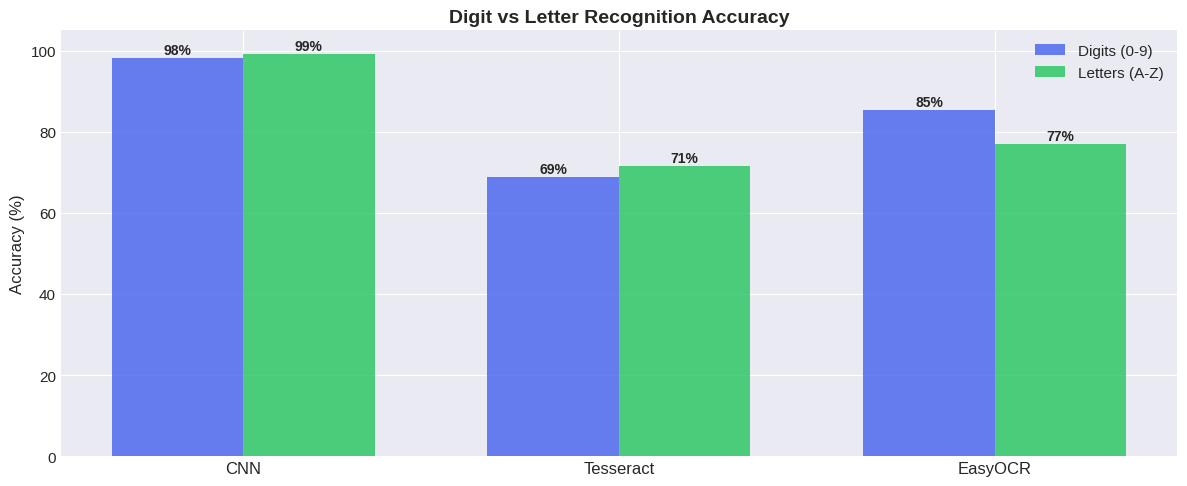

In [20]:
# Digit vs Letter accuracy comparison
fig, ax = plt.subplots(figsize=(12, 5))

digit_accs = []
letter_accs = []
for eng in engines:
    pc = results[eng]['per_class']
    d_acc = np.mean([pc[c] for c in CLASSES[:10]]) * 100
    l_acc = np.mean([pc[c] for c in CLASSES[10:]]) * 100
    digit_accs.append(d_acc)
    letter_accs.append(l_acc)

x = np.arange(len(engines))
width = 0.35

bars1 = ax.bar(x - width/2, digit_accs, width, label='Digits (0-9)', color=C['blue'], alpha=0.8)
bars2 = ax.bar(x + width/2, letter_accs, width, label='Letters (A-Z)', color=C['green'], alpha=0.8)

for bar, val in zip(bars1, digit_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.0f}%', ha='center', fontsize=10, fontweight='bold')
for bar, val in zip(bars2, letter_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.0f}%', ha='center', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(engines, fontsize=12)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Digit vs Letter Recognition Accuracy', fontweight='bold', fontsize=14)
ax.legend(fontsize=11)
ax.set_ylim(0, 105)

plt.tight_layout()
plt.show()

---
## 10. Key Takeaways

### Why OCR Engines Struggle on Single Characters

1. **No language model context**: OCR engines use language models to disambiguate similar characters (e.g., "l" vs "1" in "hello" vs "he11o"). Single characters strip this advantage entirely.

2. **Detection overhead**: OCR engines run text detection first (find text regions), then recognition. On 34×35px images, detection often fails or crops incorrectly.

3. **Resolution mismatch**: OCR engines are trained on 300 DPI scanned documents (~40-60px per character in context). Our images are already at minimum viable resolution.

4. **Architecture mismatch**: CRNN architectures (EasyOCR, PaddleOCR) expect sequences of characters. A single character is a degenerate case — like using a sentence translator for single words.

### When to Use What

| Task | Best Tool | Why |
|------|-----------|-----|
| Single character / digit recognition | **CNN classifier** | Purpose-built for the task |
| Scanned documents (invoices, PDFs) | **PaddleOCR** | Best speed/accuracy balance ([blog results](https://tildalice.io/ocr-tesseract-easyocr-paddleocr-benchmark/)) |
| Scene text (photos, signs) | **EasyOCR** | Best accuracy on noisy backgrounds |
| Legacy systems / maximum compatibility | **Tesseract** | Widest deployment, no Python dependency |
| Handwriting recognition | **Specialized CNN/Transformer** | None of the above handle handwriting well |

### The Takeaway

> **There is no universal "best" OCR engine. The right tool depends entirely on your input data.**
>
> On documents, PaddleOCR and EasyOCR shine. On isolated characters, a simple CNN crushes all three OCR engines combined.

---

### Read the Full Benchmark

This notebook is a companion to our detailed blog post on [TildAlice](https://tildalice.io):

- **[Tesseract vs EasyOCR vs PaddleOCR Benchmark](https://tildalice.io/ocr-tesseract-easyocr-paddleocr-benchmark/)** — Full document-level benchmarks with real invoices, PDFs, and scene text. Includes CER/WER metrics, setup guides, and production recommendations.

More AI and data science content: [tildalice.io](https://tildalice.io)